# 02 — Data Preprocessing & Feature Engineering
**Project:** Behavioral Anomaly Detection in Human Chess  
**Course:** BCSAI - Machine Learning Foundations  

This notebook documents every preprocessing and feature engineering decision made before data reaches the models.  
Objectives:
- Justify each cleaning and filtering step (missing values, short games, minimum game counts)
- Explain the game → player reshape
- Document each engineered feature and its anomaly-detection motivation
- Demonstrate how the train/val/test split is performed and why the scaler is fit **only on training data**

In [ ]:
from pathlib import Path
import sys

_root = Path.cwd().resolve()
if not (_root / "src").is_dir():
    _root = (_root / "..").resolve()
sys.path.insert(0, str(_root))

RESULTS_DIR = _root / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("muted")

from src.data_loader import load_raw, validate_schema, parse_time_control, clean, to_player_level
from src.features import (
    aggregate_player_stats, add_engineered_features, get_feature_matrix,
    BAND_Z_PAIRS, compute_band_stats, reapply_band_zscores,
)
from src.config import RANDOM_SEED, MIN_GAMES_PER_PLAYER, RATING_BANDS, RATING_BAND_LABELS

## 1. Load Raw Data

In [2]:
df_raw = load_raw()
print(f"Raw dataset: {df_raw.shape[0]:,} games × {df_raw.shape[1]} columns")
df_raw.head(3)

INFO:src.data_loader:Loading raw data from /Users/georgy.lifshitz/Final-Group-Project-Machine-Learning/data/raw/games.csv
INFO:src.data_loader:Loaded 20,058 games, 16 columns


Raw dataset: 20,058 games × 16 columns


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3


## 2. Missing Values

We first identify which columns have missing data and decide how to handle each one.

In [3]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]

if missing_df.empty:
    print("No missing values found in any column.")
else:
    print(missing_df)

No missing values found in any column.


**Imputation strategy:**  
- `winner`: Missing indicates a draw (Lichess encodes draws as null). We fill with the string `'draw'` — this is domain knowledge, not an assumption.
- `white_rating`, `black_rating`, `moves`, `turns`: Any row missing these cannot be analysed. We **drop** these rows rather than impute, because there is no sensible value to substitute for a missing rating or move list. The fraction of such rows is small (verified below) so the loss of data is acceptable.
- All other columns (e.g. `opening_eco`, `opening_name`) are not used in the feature matrix and their missingness is irrelevant.

In [4]:
critical_cols = ["white_rating", "black_rating", "moves", "turns"]
n_critical_missing = df_raw[critical_cols].isnull().any(axis=1).sum()
print(f"Rows dropped for missing critical fields: {n_critical_missing:,} ({n_critical_missing/len(df_raw)*100:.2f}% of dataset)")

Rows dropped for missing critical fields: 0 (0.00% of dataset)


## 3. Cleaning & Filtering

Beyond missing values, we apply three additional filters with explicit justification.

In [5]:
df_tc = parse_time_control(df_raw)

n_before = len(df_tc)
df_clean = clean(df_tc)
n_after = len(df_clean)

print(f"Before cleaning: {n_before:,} games")
print(f"After  cleaning: {n_after:,} games")
print(f"Rows removed:    {n_before - n_after:,} ({(n_before - n_after)/n_before*100:.1f}%)")

INFO:src.data_loader:Dropped 0 rows with missing critical fields
INFO:src.data_loader:After cleaning: 19,716 games remain


Before cleaning: 20,058 games
After  cleaning: 19,716 games
Rows removed:    342 (1.7%)


**Filter decisions:**

| Filter | Threshold | Justification |
|---|---|---|
| Drop missing critical fields | — | No sensible imputation for ratings or moves |
| Drop games with `turns < 5` | 5 moves | Games that end in under 5 moves are resignations or disconnects, not representative play |
| Drop zero-rating rows | rating > 0 | Rating of 0 indicates an unrated or provisional account; these skew aggregated player stats |

The `winner` null → `'draw'` fill is the only true imputation, and it is deterministic from domain knowledge.

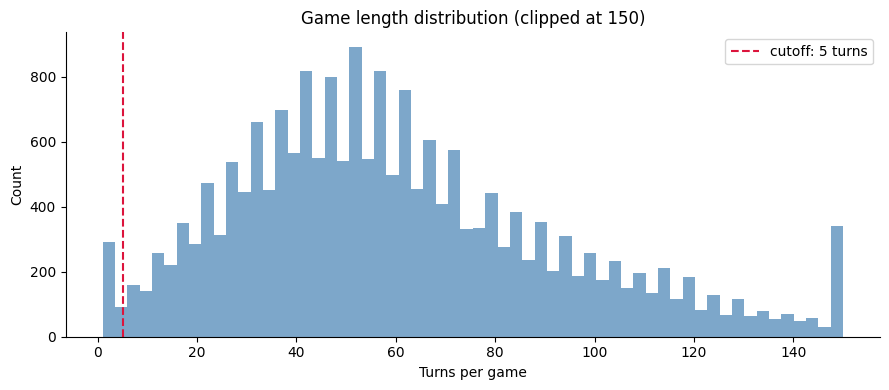

Games with < 5 turns: 1.71% of dataset


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_tc["turns"].clip(upper=150), bins=60, color="steelblue", alpha=0.7)
ax.axvline(5, color="crimson", linestyle="--", label="cutoff: 5 turns")
ax.set_xlabel("Turns per game")
ax.set_ylabel("Count")
ax.set_title("Game length distribution (clipped at 150)")
ax.legend()
plt.tight_layout()
plt.show()

pct_short = (df_tc["turns"] < 5).mean() * 100
print(f"Games with < 5 turns: {pct_short:.2f}% of dataset")

## 4. Time Control Classification

The raw `increment_code` column encodes time controls as `base+increment` (e.g. `10+0`, `5+3`).  
We classify games using the FIDE formula: **effective time = base + 40 × increment**.

FIDE-style time control thresholds used:
  bullet    — effective time < 180 s
  blitz     — 180 s ≤ effective time < 480 s
  rapid     — 480 s ≤ effective time < 1500 s
  classical — effective time ≥ 1500 s

Time control distribution after cleaning:
time_control_cat
bullet       12353
blitz         5181
rapid         1864
classical      318
Name: count, dtype: int64


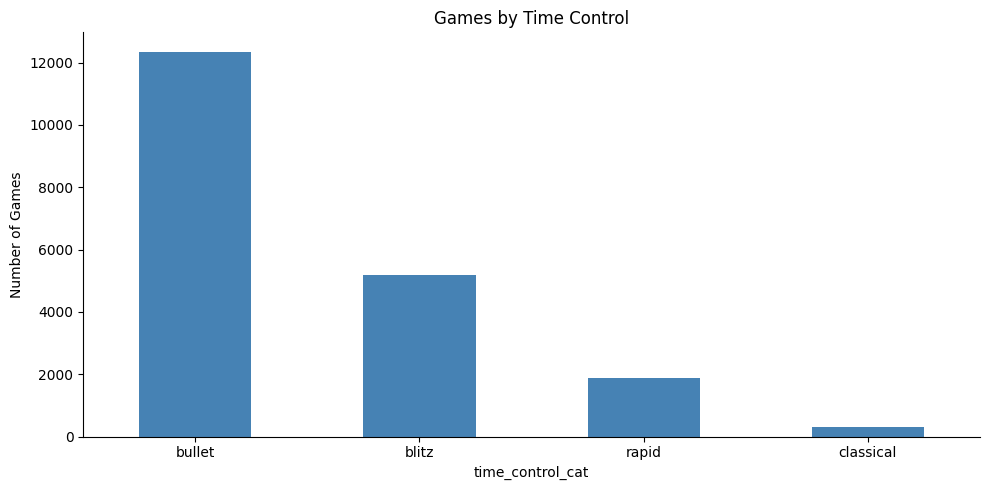


Models are trained on blitz games only (5,181 games).
Blitz is the dominant and most homogeneous time control — mixing time controls
would conflate behavioural norms across fundamentally different game speeds.


In [7]:
print("FIDE-style time control thresholds used:")
print("  bullet    — effective time < 180 s")
print("  blitz     — 180 s ≤ effective time < 480 s")
print("  rapid     — 480 s ≤ effective time < 1500 s")
print("  classical — effective time ≥ 1500 s")

tc_counts = df_clean["time_control_cat"].value_counts()
print(f"\nTime control distribution after cleaning:")
print(tc_counts)

tc_counts.plot(kind="bar", color="steelblue", rot=0)
plt.title("Games by Time Control")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

print(f"\nModels are trained on blitz games only ({tc_counts.get('blitz', 0):,} games).")
print("Blitz is the dominant and most homogeneous time control — mixing time controls")
print("would conflate behavioural norms across fundamentally different game speeds.")

## 5. Game → Player Reshape

The raw data is game-level (one row per game). Anomaly detection targets **player behaviour**, so we reshape to player-level by stacking white and black perspectives.

In [8]:
player_df = to_player_level(df_clean)

print(f"Game-level rows:   {len(df_clean):,}")
print(f"Player-level rows: {len(player_df):,}  (≈ 2× — each game yields two player records)")
print(f"Unique players:    {player_df['player_id'].nunique():,}")
player_df[["player_id", "player_rating", "opponent_rating", "won", "turns", "time_control_cat"]].head(5)

INFO:src.data_loader:Player-level dataset: 20,452 rows, 1,104 unique players


Game-level rows:   19,716
Player-level rows: 20,452  (≈ 2× — each game yields two player records)
Unique players:    1,104


,player_id,player_rating,opponent_rating,won,turns,time_control_cat
3,daniamurashov,1439,1454,1,61,bullet
7,daniel_likes_chess,1413,2108,0,9,rapid
9,daniel_likes_chess,1381,1209,1,119,bullet
10,daniel_likes_chess,1381,1272,1,39,classical
11,daniel_likes_chess,1381,1867,0,38,classical


**Minimum games filter:**  
Players with fewer than `MIN_GAMES_PER_PLAYER` games are excluded. A player with only 1–2 games has too little signal to compute reliable behavioural statistics — their aggregated features would be dominated by noise.

Minimum games threshold: 5

Games per player (after filter):
count    1104.0
mean       18.5
std        14.8
min         5.0
25%         7.0
50%        13.0
75%        27.0
max       154.0
dtype: float64


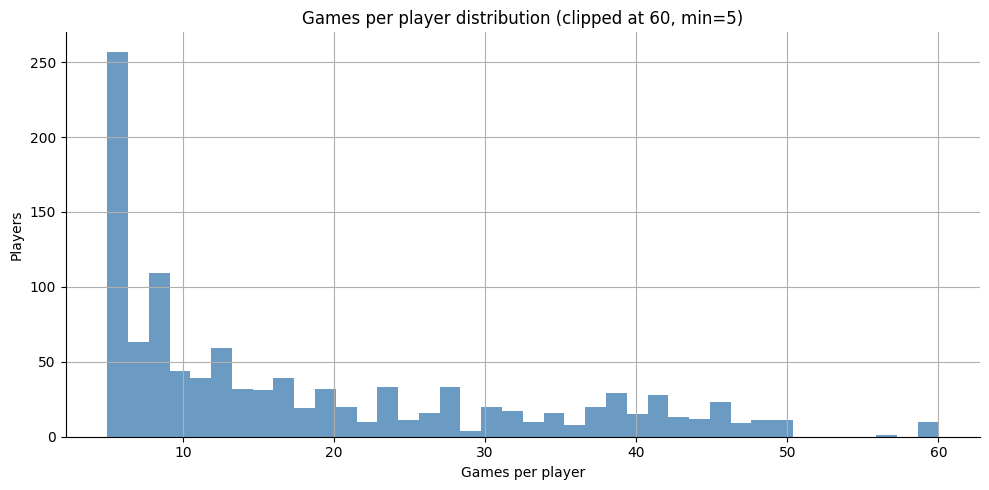

In [9]:
print(f"Minimum games threshold: {MIN_GAMES_PER_PLAYER}")

games_per_player = player_df.groupby("player_id").size()
print(f"\nGames per player (after filter):")
print(games_per_player.describe().round(1))

games_per_player.clip(upper=60).hist(bins=40, color="steelblue", alpha=0.8)
plt.xlabel("Games per player")
plt.ylabel("Players")
plt.title(f"Games per player distribution (clipped at 60, min={MIN_GAMES_PER_PLAYER})")
plt.tight_layout()
plt.show()

## 6. Feature Aggregation

We collapse the player-level records into **one row per player** by aggregating across all their games.

In [10]:
agg = aggregate_player_stats(player_df)
print(f"Aggregated player table: {agg.shape[0]:,} players × {agg.shape[1]} columns")
agg.head(3)

Aggregated player table: 1,104 players × 11 columns


,player_id,n_games,avg_rating,rating_volatility,avg_opponent_rating,win_rate,avg_turns,turns_std,avg_opening_ply,avg_rating_diff,time_control_cat
0,-l-_jedi_knight_-l-,12,1473.750000,59.137936,1494.333333,0.583333,75.583333,34.801929,3.00000,30.250000,blitz
1,1240100948,46,1699.152174,21.106047,1638.173913,0.565217,73.282609,31.288381,2.76087,40.760870,blitz
2,2700172,11,1893.363636,37.492060,1959.727273,0.272727,96.090909,35.192200,6.00000,14.909091,rapid


**Aggregation choices:**

| Column | Aggregation | Reason |
|---|---|---|
| `avg_rating` | mean | Central tendency of player strength over observed period |
| `rating_volatility` | std | High volatility may signal rapid improvement or inconsistency |
| `win_rate` | mean | Raw fraction of games won |
| `avg_turns` | mean | Typical game length — unusual lengths can signal atypical play |
| `avg_opening_ply` | mean | Average depth into known opening theory |
| `time_control_cat` | mode | Dominant time control for the player |

`rating_volatility` NaN (players with exactly 1 game after the filter) is filled with 0.

## 7. Feature Engineering

Raw aggregates do not account for rating context. A 70% win rate means something very different at 800 Elo vs 2200 Elo. We engineer four features that normalise behaviour relative to expected performance.

In [11]:
agg = add_engineered_features(agg)

print("Engineered features added:")
eng_cols = ["opening_ply_ratio", "victory_efficiency", "expected_win_rate", "win_rate_vs_expected", "rating_band"]
print(agg[eng_cols].describe().round(4))

INFO:src.features:Engineered features added. Shape: (1104, 16)


Engineered features added:
       opening_ply_ratio  victory_efficiency  expected_win_rate  \
count          1104.0000           1104.0000          1104.0000   
mean              0.0031              0.0382             0.4923   
std               0.0009              0.0099             0.2155   
min               0.0008              0.0041             0.0036   
25%               0.0025              0.0322             0.3579   
50%               0.0030              0.0376             0.4949   
75%               0.0035              0.0441             0.6324   
max               0.0096              0.0911             0.9973   

       win_rate_vs_expected  
count             1104.0000  
mean                -0.0216  
std                  0.1910  
min                 -0.8222  
25%                 -0.1184  
50%                 -0.0260  
75%                  0.0782  
max                  0.7222  


**Feature definitions and anomaly motivation:**

| Feature | Formula | Anomaly signal |
|---|---|---|
| `opening_ply_ratio` | `avg_opening_ply / (avg_rating + 1)` | A low-rated player playing deep opening theory at rates expected of much higher-rated players |
| `victory_efficiency` | `avg_turns / avg_opponent_rating` | Winning quickly against strong opponents is anomalous for a low-rated player |
| `expected_win_rate` | Elo formula: `1 / (1 + 10^((opp − self) / 400))` | Theoretical win rate given rating difference — standard chess probability model |
| `win_rate_vs_expected` | `win_rate − expected_win_rate` | Large positive values mean a player outperforms their rating consistently |

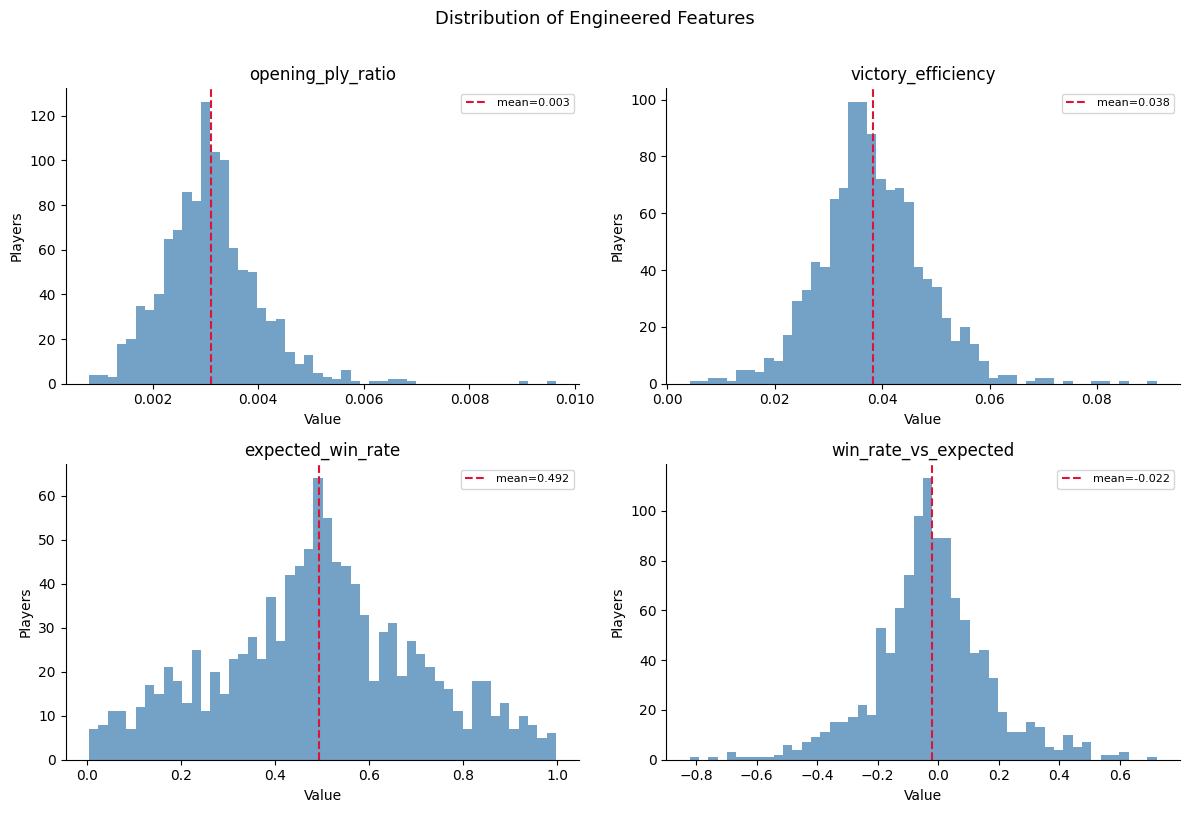

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, ["opening_ply_ratio", "victory_efficiency", "expected_win_rate", "win_rate_vs_expected"]):
    data = agg[col].dropna()
    ax.hist(data, bins=50, color="steelblue", alpha=0.75)
    ax.axvline(data.mean(), color="crimson", linestyle="--", label=f"mean={data.mean():.3f}")
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Players")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Engineered Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "feature_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Rating Bands

Anomaly detection compares players to each other. Comparing a 900-rated player's win rate to a 2100-rated player's is misleading. We assign each player to one of nine rating bands so that within-band analysis is possible.

Players per rating band:
rating_band
<800           0
800-1000      11
1000-1200     93
1200-1400    198
1400-1600    295
1600-1800    230
1800-2000    158
2000-2200     80
2200+         39
Name: count, dtype: int64


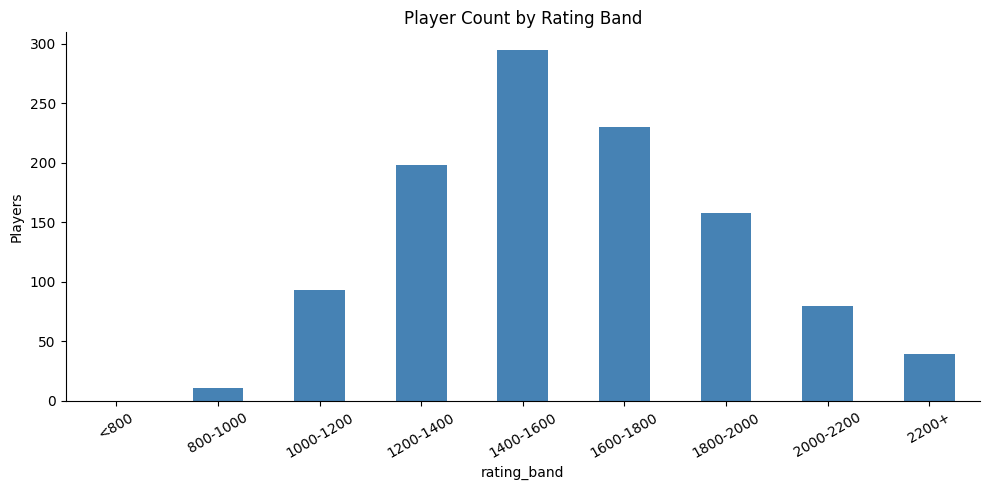

In [13]:
band_counts = agg["rating_band"].value_counts().sort_index()
print("Players per rating band:")
print(band_counts)

band_counts.plot(kind="bar", color="steelblue", rot=30)
plt.title("Player Count by Rating Band")
plt.ylabel("Players")
plt.tight_layout()
plt.show()

## 9. Outlier Analysis

Because we are doing **anomaly detection**, we deliberately retain outliers — they are the signal we are looking for. However, we inspect extreme values to confirm they are genuine data points, not data errors.

In [14]:
feature_cols = ["win_rate", "win_rate_vs_expected", "avg_turns", "opening_ply_ratio",
                "victory_efficiency", "rating_volatility"]

print("Extreme values (> 3 standard deviations from mean):")
for col in feature_cols:
    series = agg[col].dropna()
    z = (series - series.mean()) / series.std()
    n_extreme = (z.abs() > 3).sum()
    print(f"  {col:30s}  {n_extreme:4d} extreme players  ({n_extreme/len(series)*100:.1f}%)")

Extreme values (> 3 standard deviations from mean):
  win_rate                           0 extreme players  (0.0%)
  win_rate_vs_expected              16 extreme players  (1.4%)
  avg_turns                         10 extreme players  (0.9%)
  opening_ply_ratio                  9 extreme players  (0.8%)
  victory_efficiency                11 extreme players  (1.0%)
  rating_volatility                 25 extreme players  (2.3%)


**Decision:** We do **not** clip or remove outliers. These extreme players are exactly what our anomaly detectors are designed to surface. Removing them would destroy the signal. The only values we cap are internal to feature construction (e.g. `clip(lower=1)` on `avg_opponent_rating` to prevent division by zero).

## 10. Train / Validation / Test Split

We split **before** fitting any scaler or transformation. This is the core leakage-prevention step.

In [15]:
X_raw, meta, _ = get_feature_matrix(agg, fit_scaler=False, time_control="blitz")
feature_names = list(X_raw.columns)
X_arr = X_raw.values

train_idx, temp_idx = train_test_split(np.arange(len(X_arr)), test_size=0.30, random_state=RANDOM_SEED)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50, random_state=RANDOM_SEED)

print(f"Total players (blitz): {len(X_arr):,}")
print(f"  Train : {len(train_idx):,}  ({len(train_idx)/len(X_arr)*100:.0f}%)")
print(f"  Val   : {len(val_idx):,}   ({len(val_idx)/len(X_arr)*100:.0f}%)")
print(f"  Test  : {len(test_idx):,}   ({len(test_idx)/len(X_arr)*100:.0f}%)")

INFO:src.features:Filtered to time control 'blitz': 299 players
INFO:src.features:Feature matrix: 299 players × 6 features (scaled=False)


Total players (blitz): 299
  Train : 209  (70%)
  Val   : 45   (15%)
  Test  : 45   (15%)


**Split rationale (70 / 15 / 15):**

- **Training (70%):** Sufficient data for all five models to learn the normal behaviour distribution.
- **Validation (15%):** Used for hyperparameter tuning via synthetic anomaly injection. Kept separate from training so tuning decisions are not influenced by test-set statistics.
- **Test (15%):** Held out completely and touched only once, at the very end of the pipeline. Provides an unbiased estimate of final model performance.

A 70/15/15 split is standard for datasets of this size. K-fold cross-validation is additionally run on the development set (train + val) to estimate variance.

## 11. Feature Scaling — Leakage Prevention

StandardScaler is fit **only on the training split**, then applied to val and test. Fitting on the full dataset would leak val/test statistics (mean, std) into the scaler — a subtle but real form of data leakage that inflates reported performance.

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_arr[train_idx])  # fit on train only
X_val   = scaler.transform(X_arr[val_idx])         # apply same transform
X_test  = scaler.transform(X_arr[test_idx])        # apply same transform

print("Scaler statistics (learned from training data only):")
scaler_stats = pd.DataFrame({"feature": feature_names, "mean": scaler.mean_, "std": scaler.scale_})
print(scaler_stats.round(4).to_string(index=False))

Scaler statistics (learned from training data only):
             feature    mean     std
            win_rate  0.4557  0.2545
win_rate_vs_expected -0.0177  0.2013
           avg_turns 59.5954 13.6038
   opening_ply_ratio  0.0030  0.0009
  victory_efficiency  0.0378  0.0087
   rating_volatility 48.6029 54.8460


/var/folders/98/tyzf0m0d3zv1ht7bpswr_d340000gp/T/ipykernel_18396/3250963832.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(X_arr[train_idx], labels=feature_names, vert=True)
/var/folders/98/tyzf0m0d3zv1ht7bpswr_d340000gp/T/ipykernel_18396/3250963832.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(X_train, labels=feature_names, vert=True)


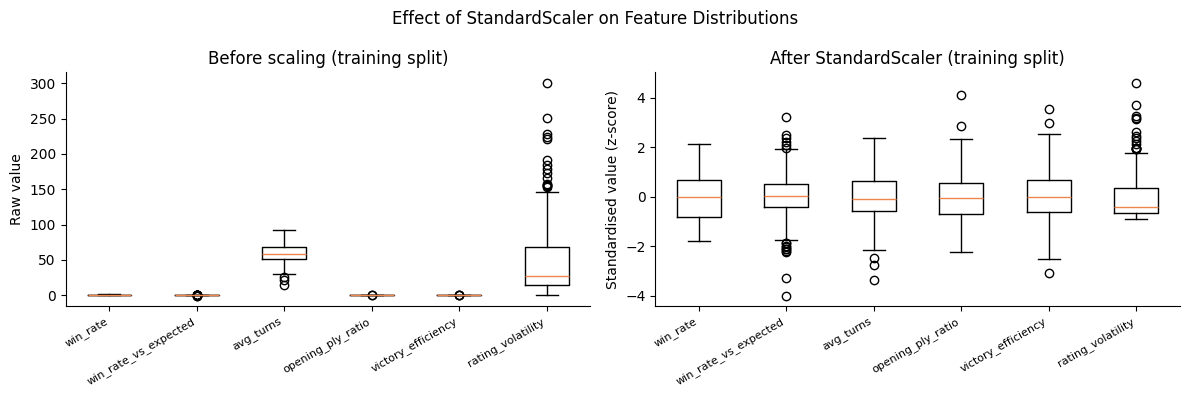

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(X_arr[train_idx], labels=feature_names, vert=True)
axes[0].set_title("Before scaling (training split)")
axes[0].set_xticklabels(feature_names, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("Raw value")

axes[1].boxplot(X_train, labels=feature_names, vert=True)
axes[1].set_title("After StandardScaler (training split)")
axes[1].set_xticklabels(feature_names, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("Standardised value (z-score)")

plt.suptitle("Effect of StandardScaler on Feature Distributions", fontsize=12)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "scaling_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11b. Band Z-Score Leakage Fix (Stage 2e)

Within-rating-band z-scores for ACPL features (e.g. `avg_acpl_band_z`, `best_move_rate_band_z`) are computed by `add_engineered_features()` using the full player table — **before** the train/val/test split above. This means band statistics (per-band mean and std) are computed from val and test players as well, leaking their distribution into the normalisation applied to training data.

**Fix:** after the split is known, we recompute all `*_band_z` columns using **training-player statistics only**, then propagate the corrected values back into `X_arr` and refit the scaler.

This is the `Stage 2e` step in `src/pipeline.py`.

In [ ]:
# Stage 2e: recompute band z-scores from training players only
train_pids = set(meta.iloc[train_idx]["player_id"])
band_stats = compute_band_stats(agg[agg["player_id"].isin(train_pids)])
agg_corrected = reapply_band_zscores(agg.copy(), band_stats)

# Show how band stats differ when computed from train-only vs full dataset
print("Band z-score correction (training-only stats vs full-dataset stats):")
print("Feature pairs being corrected:", [z for _, z in BAND_Z_PAIRS if z in agg.columns])

# Propagate corrected values back into X_arr and refit scaler
agg_indexed = agg_corrected.set_index("player_id")
for _raw_feat, z_feat in BAND_Z_PAIRS:
    if z_feat not in feature_names:
        continue
    col_idx = feature_names.index(z_feat)
    for row_i, pid in enumerate(meta["player_id"]):
        if pid in agg_indexed.index:
            val = agg_indexed.at[pid, z_feat]
            if pd.notna(val):
                X_arr[row_i, col_idx] = float(val)

# Refit scaler on the corrected training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_arr[train_idx])
X_val   = scaler.transform(X_arr[val_idx])
X_test  = scaler.transform(X_arr[test_idx])

print("\nScaler refit on training data after band z-score correction.")
print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")

## 12. Feature Correlation

We inspect pairwise correlations among the final features to check for redundancy. High correlation between features can cause some models (particularly distance-based ones like OC-SVM and LOF) to over-weight the correlated dimension.

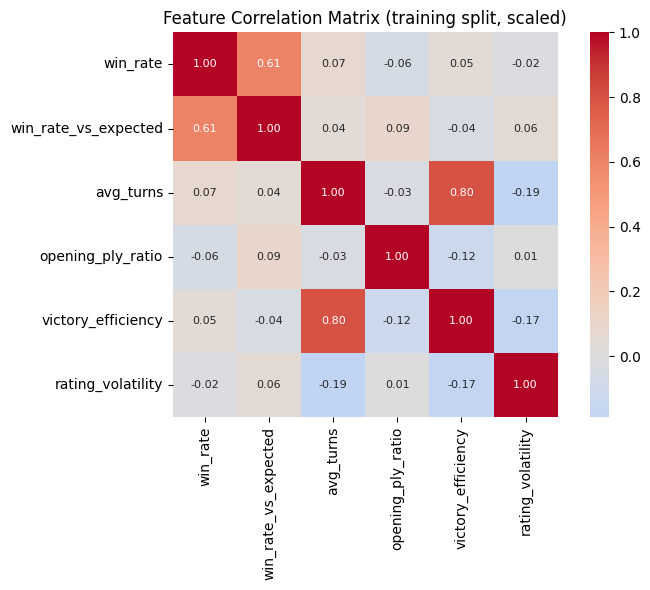

High-correlation pairs (|r| > 0.7):
  avg_turns — victory_efficiency: 0.801


In [18]:
train_df = pd.DataFrame(X_train, columns=feature_names)
corr_matrix = train_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Feature Correlation Matrix (training split, scaled)")
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / "feature_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

# Flag high correlations (|r| > 0.7, excluding diagonal)
high_corr = [
    (r, c, corr_matrix.loc[r, c])
    for r in corr_matrix.columns
    for c in corr_matrix.columns
    if r < c and abs(corr_matrix.loc[r, c]) > 0.7
]
if high_corr:
    print("High-correlation pairs (|r| > 0.7):")
    for r, c, v in high_corr:
        print(f"  {r} — {c}: {v:.3f}")
else:
    print("No feature pairs with |r| > 0.7. No dimensionality reduction required.")

## 13. Final Feature Matrix Summary

In [19]:
print(f"Features used: {feature_names}")
print(f"\nFinal split sizes:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")
print(f"\nNaN values in train: {np.isnan(X_train).sum()}")
print(f"NaN values in val:   {np.isnan(X_val).sum()}")
print(f"NaN values in test:  {np.isnan(X_test).sum()}")

pd.DataFrame(X_train, columns=feature_names).describe().round(3)

Features used: ['win_rate', 'win_rate_vs_expected', 'avg_turns', 'opening_ply_ratio', 'victory_efficiency', 'rating_volatility']

Final split sizes:
  Train : (209, 6)
  Val   : (45, 6)
  Test  : (45, 6)

NaN values in train: 0
NaN values in val:   0
NaN values in test:  0


,win_rate,win_rate_vs_expected,avg_turns,opening_ply_ratio,victory_efficiency,rating_volatility
count,209.000,209.000,209.000,209.000,209.000,209.000
mean,0.000,-0.000,0.000,-0.000,0.000,-0.000
std,1.002,1.002,1.002,1.002,1.002,1.002
min,-1.790,-3.996,-3.366,-2.242,-3.079,-0.886
25%,-0.808,-0.418,-0.594,-0.685,-0.631,-0.637
50%,-0.026,0.019,-0.107,-0.040,-0.021,-0.399
75%,0.665,0.526,0.633,0.535,0.671,0.359
max,2.139,3.213,2.391,4.115,3.550,4.593


## 14. Summary

| Step | Decision | Justification |
|---|---|---|
| Missing ratings / moves | Drop rows | No sensible imputation; <1% of data |
| Missing `winner` | Fill with `'draw'` | Domain knowledge: Lichess encodes draws as null |
| Games < 5 turns | Drop | Resignations / disconnects, not representative play |
| Min games per player | ≥ 5 | Too few games → unreliable behavioural statistics |
| Time control filter | Blitz only | Dominant class; mixing TCs conflates behavioural norms |
| Outliers | Retained | They are the detection target — removal would destroy signal |
| Split | 70 / 15 / 15 | Standard for this data size; test set touched once only |
| Scaling | StandardScaler fit on train only | Prevents leakage of val/test statistics into the scaler |
| Engineered features | 4 ratio features + rating band | Normalise for rating context; raw stats are misleading across Elo ranges |
| Band z-scores (Stage 2e) | Recomputed from training players only | `add_engineered_features` uses the full table before the split, so initial band stats include val/test players. Stage 2e corrects this by recomputing per-band mean/std from train fold only and propagating the corrected values back into `X_arr` before the scaler is refit. |